# Proyecto 2 — Análisis Inicial y Selección de Problema

**Etapa:** Parte I — Búsqueda, EDA inicial y Selección de Problema  

---

##Datasets analizados

| # | Dataset | Fuente | Dominio | Problema |
|---|---------|--------|---------|----------|
| 1 | Bank Customer Churn | Kaggle | Banca / Finanzas | Clasificación |
| 2 | Heart Disease | Kaggle | Salud / Medicina | Clasificación |
| 3 | Video Game Sales + Metacritic | Kaggle | Entretenimiento | Regresión |
| 4 | Most Streamed Spotify Songs 2024 | Kaggle | Música / Streaming | Regresión |

---


# Diccionario de Columnas — Proyecto 2

---

##  Dataset 1 — Bank Customer Churn
**Archivo:** `Customer-Churn-Records.csv` | **Filas:** 10.000 | **Columnas:** 18

| # | Columna (original) | Traducción | Tipo | Descripción |
|---|---|---|---|---|
| 1 | RowNumber | Número de fila | int | Número de registro. No tiene efecto en la predicción |
| 2 | CustomerId | ID de cliente | int | Identificador único del cliente. No influye en el churn |
| 3 | Surname | Apellido | str | Apellido del cliente. No tiene impacto en la decisión de abandonar |
| 4 | CreditScore | Puntaje crediticio | int | Puntaje de crédito del cliente. Mayor puntaje = menor probabilidad de abandono |
| 5 | Geography | País | str | País de residencia del cliente (France, Spain, Germany) |
| 6 | Gender | Género | str | Género del cliente (Male = Masculino / Female = Femenino) |
| 7 | Age | Edad | int | Edad del cliente. Clientes mayores tienden a ser más leales |
| 8 | Tenure | Antigüedad | int | Años que el cliente lleva en el banco. Mayor antigüedad = más lealtad |
| 9 | Balance | Saldo en cuenta | float | Saldo disponible en la cuenta. Saldos altos se asocian a menor churn |
| 10 | NumOfProducts | N° de productos | int | Cantidad de productos bancarios contratados por el cliente |
| 11 | HasCrCard | ¿Tiene tarjeta de crédito? | int | Indica si posee tarjeta de crédito (1 = Sí / 0 = No) |
| 12 | IsActiveMember | ¿Es miembro activo? | int | Los clientes activos son menos propensos a abandonar (1 = Sí / 0 = No) |
| 13 | EstimatedSalary | Salario estimado | float | Salario estimado del cliente. Salarios bajos se asocian a mayor churn |
| 14 | **Exited** | **¿Abandonó el banco?** | int | **Variable objetivo: 1 = abandonó el banco / 0 = permanece** |
| 15 | Complain | ¿Presentó reclamo? | int | Indica si el cliente realizó alguna queja (1 = Sí / 0 = No) |
| 16 | Satisfaction Score | Puntuación de satisfacción | int | Calificación del cliente sobre la resolución de su reclamo (1–5) |
| 17 | Card Type | Tipo de tarjeta | str | Tipo de tarjeta de crédito que posee el cliente (DIAMOND, GOLD, SILVER, PLATINUM) |
| 18 | Point Earned | Puntos acumulados | int | Puntos de fidelidad ganados mediante el uso de la tarjeta de crédito |

---

---
# Sección 0 — Configuración del entorno

Lo primero que debemos hacer es conectarnos al drive para poder acceder a los dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Librerías
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [ ]:
#  Función reutilizable: resumen de nulos
def resumen_nulos(df, titulo=''):
    null_df = pd.DataFrame({
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / len(df) * 100).round(1)
    }).sort_values('% Nulos', ascending=False)
    null_df = null_df[null_df['Nulos'] > 0]
    if null_df.empty:
        print(f'{titulo}: Sin valores nulos.')
        return null_df
    print(f'\n Nulos en {titulo}:')
    print(null_df.to_string())
    return null_df

# Función reutilizable: outliers IQR
def resumen_outliers(df, cols, nombre=''):
    rows = []
    for col in cols:
        if col not in df.columns: continue
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        n = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
        rows.append({
            'Variable': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
            'IQR': round(IQR, 2), 'N Outliers': n,
            '% Outliers': round(n / len(data) * 100, 2)
        })
    result = pd.DataFrame(rows)
    if not result.empty:
        print(f'\n [{nombre}] Resumen de outliers (método IQR):')
        display(result)
    return result


---
# Dataset 1 — Bank Customer Churn
**Fuente:** Kaggle — `radheshyamkollipara/bank-customer-churn`  
**Dominio:** Banca / Finanzas  
**Problema:** Clasificación binaria:  predecir si un cliente abandonará el banco

## 1.1 Descripción del conjunto de datos

Dataset de **10.000 clientes** de un banco multinacional con variables demográficas, financieras y de comportamiento.  
El target `Exited` indica si el cliente abandonó el banco (1) o permanece (0).

Existen algunas columnas que en verdad no nos interesan:


|  Columna | Descripción |
|---|---|
| RowNumber | Número de registro. No tiene efecto en la predicción |
|  CustomerId | Identificador único del cliente. No influye en el churn |
|  Surname |  Apellido del cliente. No tiene impacto en la decisión de abandonar |

por lo que las eliminaremos de inmediato al cargar el dataset

## 1.2 Descarga y carga de datos

In [ ]:
df_bank=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/Customer-Churn-Records.csv')
df_bank.drop(columns=[c for c in ['RowNumber','CustomerId','Surname'] if c in df_bank.columns], inplace=True)
print(f' Dataset cargado: {df_bank.shape[0]:,} filas × {df_bank.shape[1]} columnas')
print(f'Columnas: {df_bank.columns.tolist()}')
df_bank.head()

 Dataset cargado: 10,000 filas × 15 columnas
Columnas: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 1.3 Análisis estadístico descriptivo

In [ ]:
print(f'Informacion del dataset: \n')
df_bank.info()

print(f'\nPrimeras 5 filas: \n\n {df_bank.head()}\n')
print(f'Últimas 5 filas: \n\n {df_bank.tail()}\n')
print(f'Cantidad de elementos duplicados:\n\n {df_bank.duplicated()}\n')
print(f'Cantidad de elementos nulos:\n \n{df_bank.isnull().sum()}\n')
print(f'Tipos de datos :\n \n {df_bank.dtypes.to_string()}')

Informacion del dataset: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  Complain            10000 non-null  int64  
 12  Satisfaction Score  10000 non-null  int64  
 13  Card Type           10000 non-null  object 
 14  Point Earned        10000 non-null  int64  
dtypes: float64(2), int64(10), o

In [ ]:
print('\n Estadísticas numéricas ')
#esta forma de mostrar las estadisticas de un modo mas "agradable", viene de la IA
# lo encontre más ordenado y quice aplicarlo.
#se puede apreciar que las variables( columnas) estan ordenadas en vertical
#y no horizontal como lo hace normalmente el .describe()
num1 = df_bank.select_dtypes(include=np.number)
desc1 = num1.describe().T
desc1['skewness'] = num1.skew().round(3)
desc1['cv'] = (desc1['std'] / desc1['mean']).round(3)
display(desc1.style.background_gradient(cmap='Blues', subset=['mean','std']))


print('\n Variables categóricas')
for col in df_bank.select_dtypes(include='object').columns:
    print(df_bank[col].value_counts(normalize=True).map(lambda x: f'{x:.1%}').to_string())
    print('\n')


 Estadísticas numéricas 


,count,mean,std,min,25%,50%,75%,max,skewness,cv
CreditScore,10000.000000,650.528800,96.653299,350.000000,584.000000,652.000000,718.000000,850.000000,-0.072000,0.149000
Age,10000.000000,38.921800,10.487806,18.000000,32.000000,37.000000,44.000000,92.000000,1.011000,0.269000
Tenure,10000.000000,5.012800,2.892174,0.000000,3.000000,5.000000,7.000000,10.000000,0.011000,0.577000
Balance,10000.000000,76485.889288,62397.405202,0.000000,0.000000,97198.540000,127644.240000,250898.090000,-0.141000,0.816000
NumOfProducts,10000.000000,1.530200,0.581654,1.000000,1.000000,1.000000,2.000000,4.000000,0.746000,0.380000
HasCrCard,10000.000000,0.705500,0.455840,0.000000,0.000000,1.000000,1.000000,1.000000,-0.902000,0.646000
IsActiveMember,10000.000000,0.515100,0.499797,0.000000,0.000000,1.000000,1.000000,1.000000,-0.060000,0.970000
EstimatedSalary,10000.000000,100090.239881,57510.492818,11.580000,51002.110000,100193.915000,149388.247500,199992.480000,0.002000,0.575000
Exited,10000.000000,0.203800,0.402842,0.000000,0.000000,0.000000,0.000000,1.000000,1.471000,1.977000
Complain,10000.000000,0.204400,0.403283,0.000000,0.000000,0.000000,0.000000,1.000000,1.466000,1.973000



 Variables categóricas
Geography
France     50.1%
Germany    25.1%
Spain      24.8%


Gender
Male      54.6%
Female    45.4%


Card Type
DIAMOND     25.1%
GOLD        25.0%
SILVER      25.0%
PLATINUM    24.9%




In [ ]:
nulos1 = resumen_nulos(df_bank, 'Bank Customer Churn')

if not nulos1.empty:
    plt.figure(figsize=(8,4))
    nulos1['% Nulos'].sort_values().plot(kind='barh', color='#D85A30')
    plt.title('% de nulos por columna'); plt.tight_layout(); plt.show()

print('\n Resumen de outliers (IQR):')
all_num1 = df_bank.select_dtypes(include=np.number).columns.tolist()
print(resumen_outliers(df_bank, all_num1).to_string(index=False))

Bank Customer Churn: Sin valores nulos.

 Resumen de outliers (IQR):

 [] Resumen de outliers (método IQR):


,Variable,Q1,Q3,IQR,N Outliers,% Outliers
0,CreditScore,584.00,718.00,134.00,15,0.15
1,Age,32.00,44.00,12.00,359,3.59
2,Tenure,3.00,7.00,4.00,0,0.00
3,Balance,0.00,127644.24,127644.24,0,0.00
4,NumOfProducts,1.00,2.00,1.00,60,0.60
5,HasCrCard,0.00,1.00,1.00,0,0.00
6,IsActiveMember,0.00,1.00,1.00,0,0.00
7,EstimatedSalary,51002.11,149388.25,98386.14,0,0.00
8,Exited,0.00,0.00,0.00,2038,20.38
9,Complain,0.00,0.00,0.00,2044,20.44


          Variable       Q1        Q3       IQR  N Outliers  % Outliers
       CreditScore   584.00    718.00    134.00          15        0.15
               Age    32.00     44.00     12.00         359        3.59
            Tenure     3.00      7.00      4.00           0        0.00
           Balance     0.00 127644.24 127644.24           0        0.00
     NumOfProducts     1.00      2.00      1.00          60        0.60
         HasCrCard     0.00      1.00      1.00           0        0.00
    IsActiveMember     0.00      1.00      1.00           0        0.00
   EstimatedSalary 51002.11 149388.25  98386.14           0        0.00
            Exited     0.00      0.00      0.00        2038       20.38
          Complain     0.00      0.00      0.00        2044       20.44
Satisfaction Score     2.00      4.00      2.00           0        0.00
      Point Earned   410.00    801.00    391.00           0        0.00


In [ ]:
#Veremos si existe alguna inconsistencia con los valores de algunas columnas
print(df_bank['Geography'].unique())
print(df_bank['Gender'].unique())
print(df_bank['Card Type'].unique())

['France' 'Spain' 'Germany']
['Female' 'Male']
['DIAMOND' 'GOLD' 'SILVER' 'PLATINUM']


## 1.4 Visualizaciones
### 1.4.1 Distribución del target y desbalance de clases

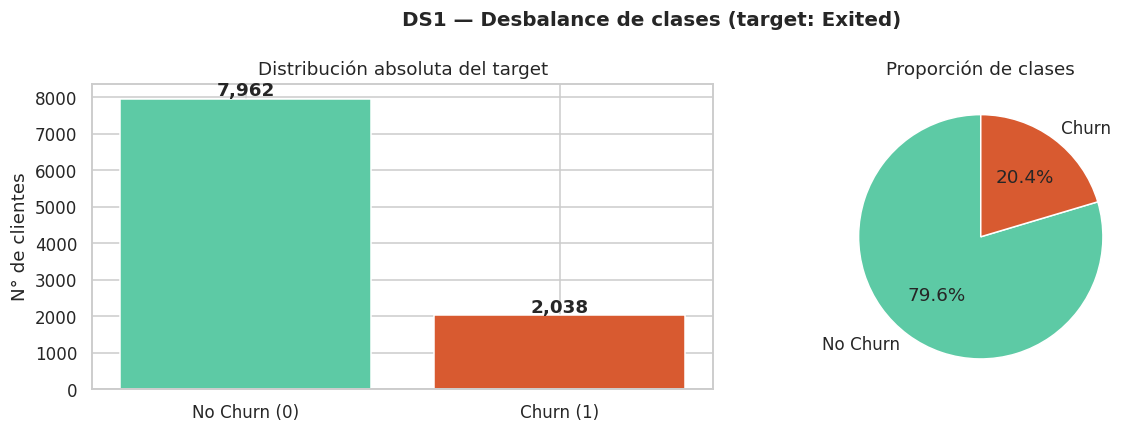

Tasa de churn: 20.4%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts1 = df_bank['Exited'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], counts1.values,
            color=['#5DCAA5','#D85A30'], edgecolor='white')
for i, v in enumerate(counts1.values):
    axes[0].text(i, v+80, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Distribución absoluta del target')
axes[0].set_ylabel('N° de clientes')

axes[1].pie(counts1.values, labels=['No Churn','Churn'],
            autopct='%1.1f%%', colors=['#5DCAA5','#D85A30'],
            startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Proporción de clases')

plt.suptitle('DS1 — Desbalance de clases (target: Exited)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Tasa de churn: {df_bank["Exited"].mean():.1%}')

### 1.4.2 Histogramas de variables numéricas por churn

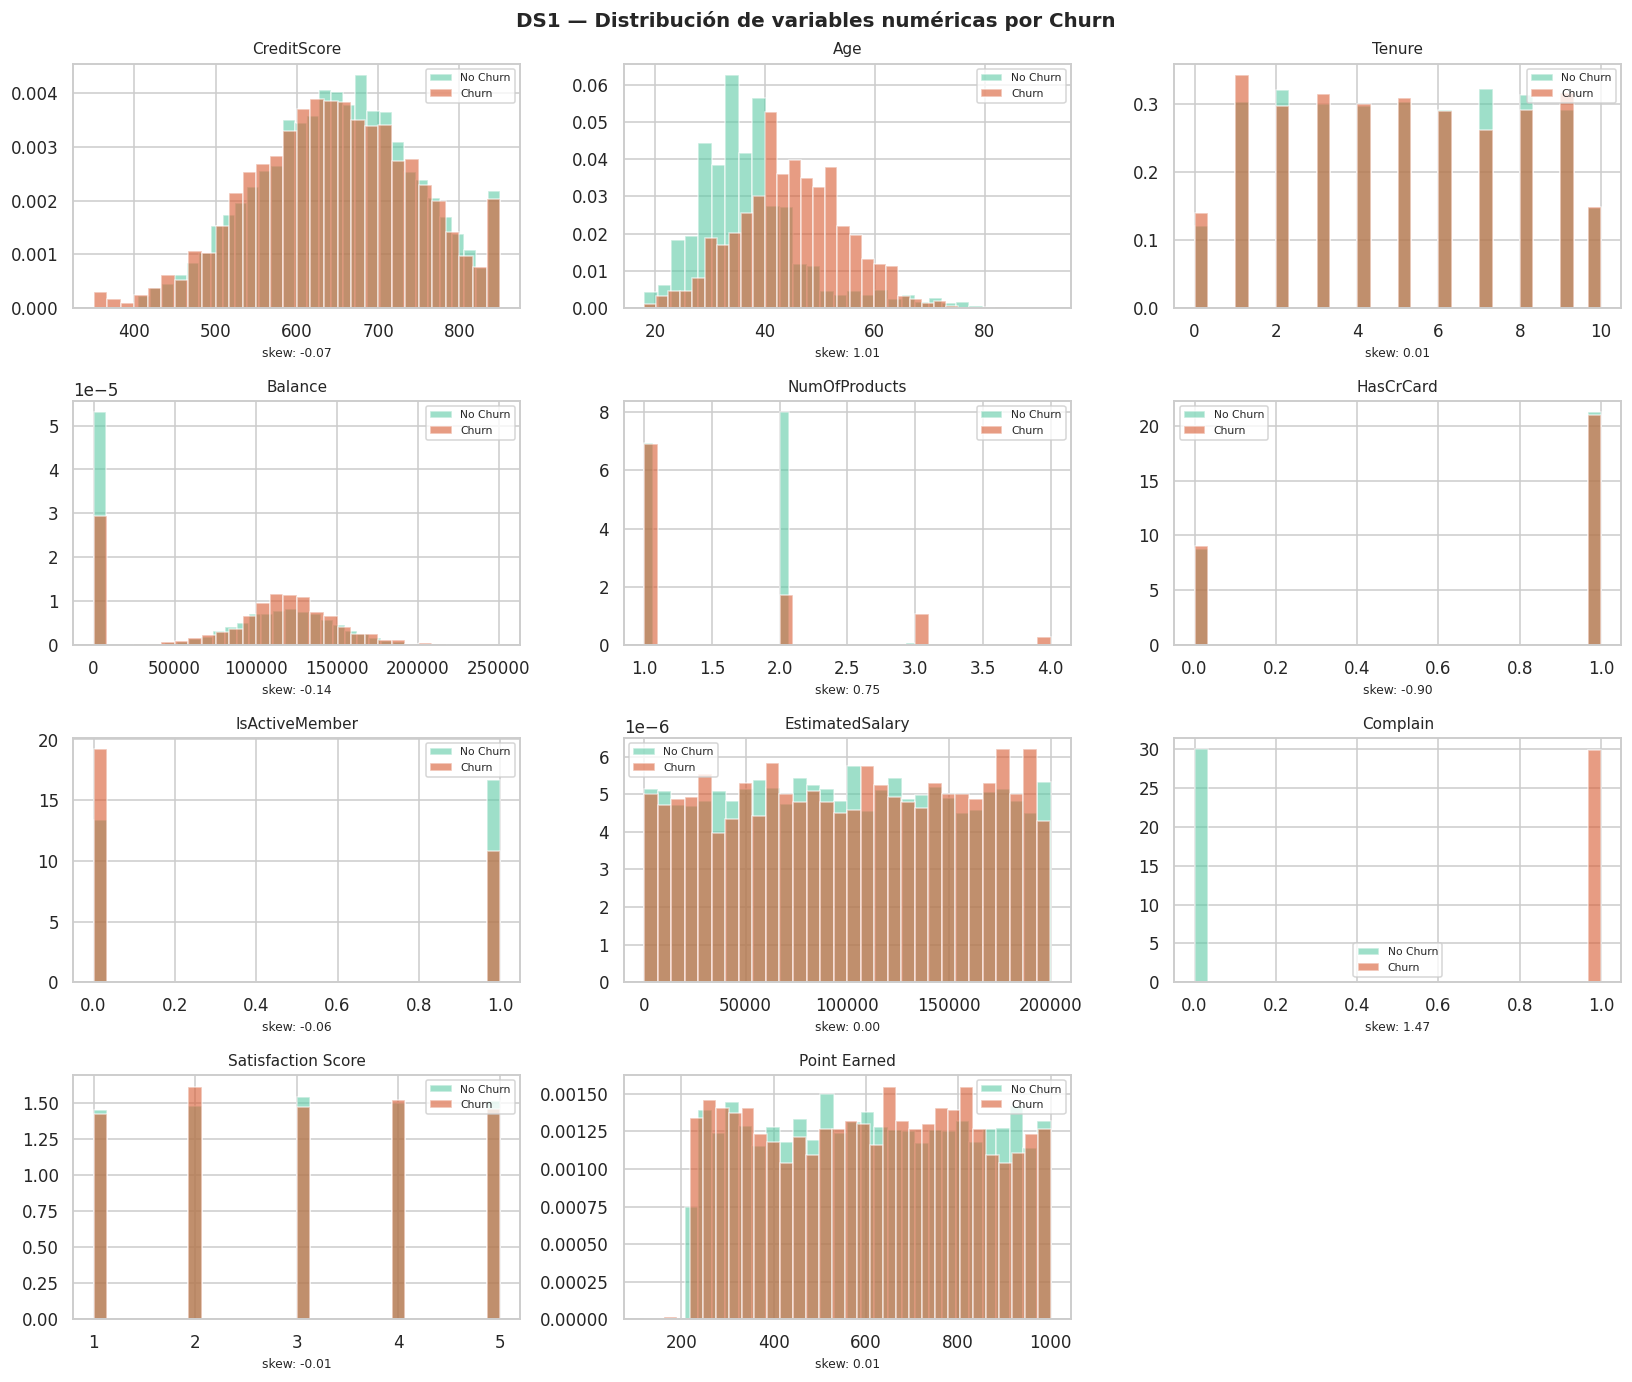

In [ ]:
num_cols1 = [c for c in df_bank.select_dtypes(include=np.number).columns if c != 'Exited']
nrows = (len(num_cols1)+2)//3
fig, axes = plt.subplots(nrows, 3, figsize=(15, nrows*3.2))
axes = axes.flatten()

for i, col in enumerate(num_cols1):
    ax = axes[i]
    for val, color, lbl in [(0,'#5DCAA5','No Churn'),(1,'#D85A30','Churn')]:
        ax.hist(df_bank[df_bank['Exited']==val][col], bins=30, alpha=0.6,
                color=color, label=lbl, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel(f'skew: {df_bank[col].skew():.2f}', fontsize=8)
for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('DS1 — Distribución de variables numéricas por Churn', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 1.4.3 Tasa de churn por variables categóricas

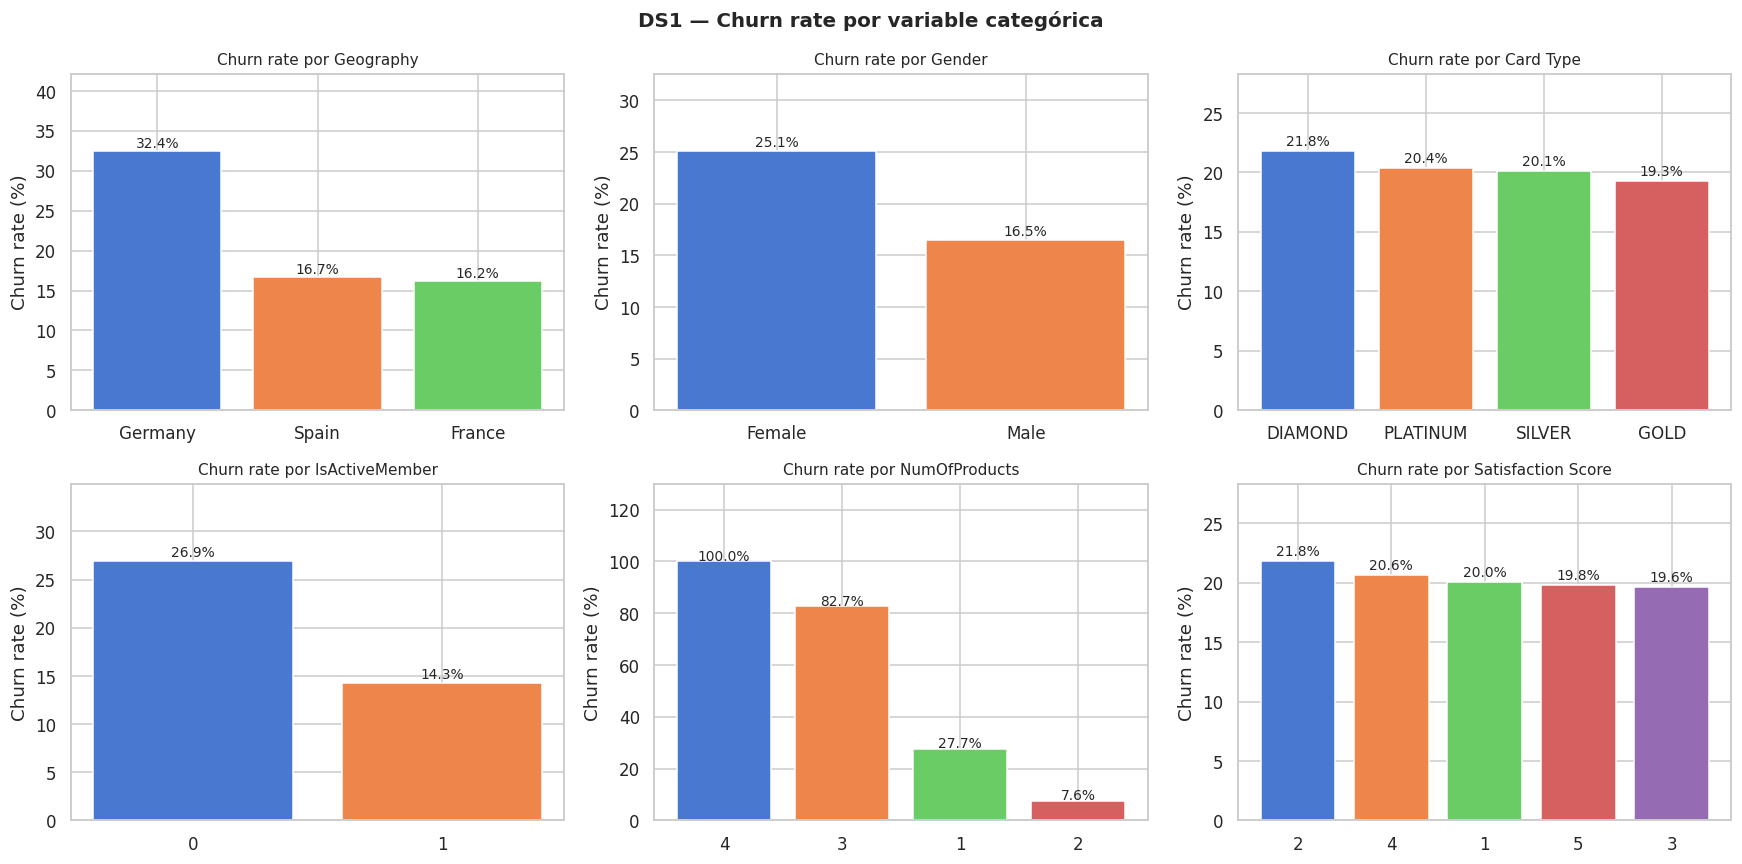

In [ ]:
plot_cats1 = ['Geography','Gender','Card Type','IsActiveMember','NumOfProducts','Satisfaction Score']
plot_cats1 = [c for c in plot_cats1 if c in df_bank.columns]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cats1):
    ax = axes[i]
    rate = df_bank.groupby(col)['Exited'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(rate.index.astype(str), rate.values,
                  color=sns.color_palette('muted', len(rate)), edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9)
    ax.set_title(f'Churn rate por {col}', fontsize=10)
    ax.set_ylabel('Churn rate (%)')
    ax.set_ylim(0, rate.max()*1.3)

plt.suptitle('DS1 — Churn rate por variable categórica', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 1.4.4 Box plots — Detección de outliers

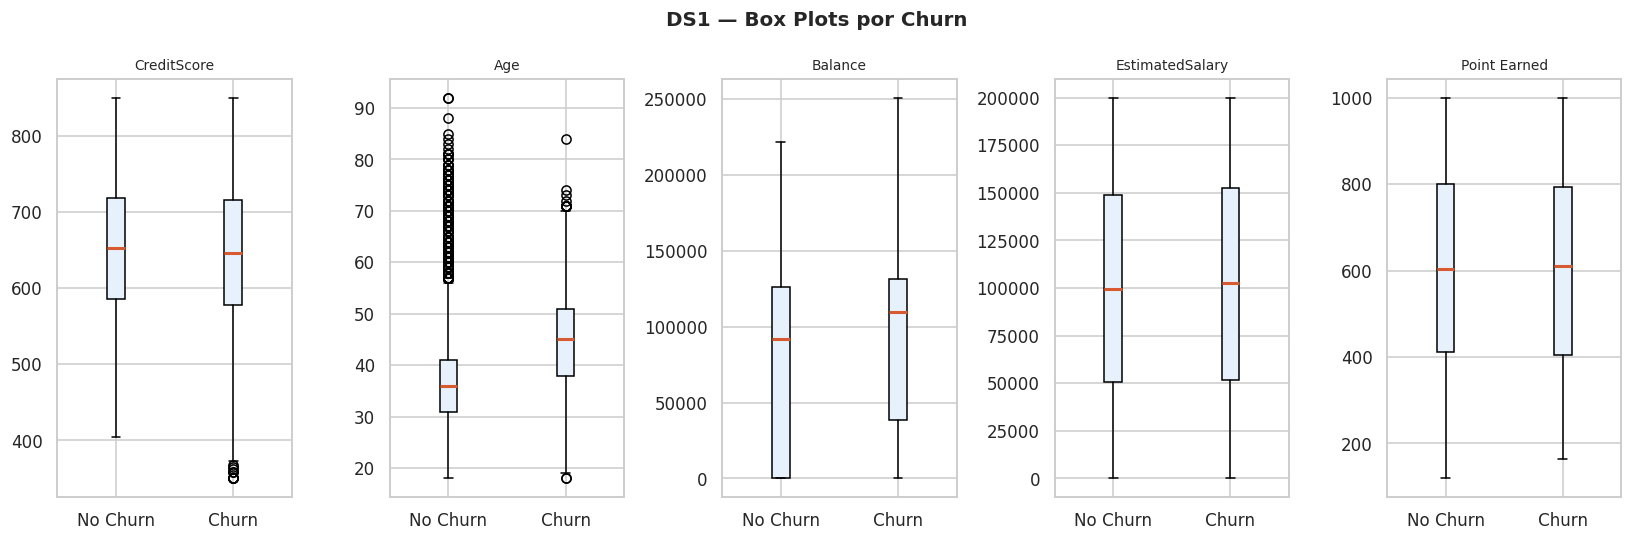


 [] Resumen de outliers (método IQR):


,Variable,Q1,Q3,IQR,N Outliers,% Outliers
0,CreditScore,584.00,718.00,134.00,15,0.15
1,Age,32.00,44.00,12.00,359,3.59
2,Balance,0.00,127644.24,127644.24,0,0.00
3,EstimatedSalary,51002.11,149388.25,98386.14,0,0.00
4,Point Earned,410.00,801.00,391.00,0,0.00


       Variable       Q1        Q3       IQR  N Outliers  % Outliers
    CreditScore   584.00    718.00    134.00          15        0.15
            Age    32.00     44.00     12.00         359        3.59
        Balance     0.00 127644.24 127644.24           0        0.00
EstimatedSalary 51002.11 149388.25  98386.14           0        0.00
   Point Earned   410.00    801.00    391.00           0        0.00


In [ ]:
box_cols1 = ['CreditScore','Age','Balance','EstimatedSalary','Point Earned']
box_cols1 = [c for c in box_cols1 if c in df_bank.columns]
fig, axes = plt.subplots(1, len(box_cols1), figsize=(15, 5))

for i, col in enumerate(box_cols1):
    ax = axes[i]
    ax.boxplot([df_bank[df_bank['Exited']==0][col], df_bank[df_bank['Exited']==1][col]],
               labels=['No Churn','Churn'], patch_artist=True,
               boxprops=dict(facecolor='#E6F1FB'),
               medianprops=dict(color='#D85A30', linewidth=2))
    ax.set_title(col, fontsize=9)

plt.suptitle('DS1 — Box Plots por Churn', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(resumen_outliers(df_bank, box_cols1).to_string(index=False))

### 1.4.5 Mapa de calor de correlaciones

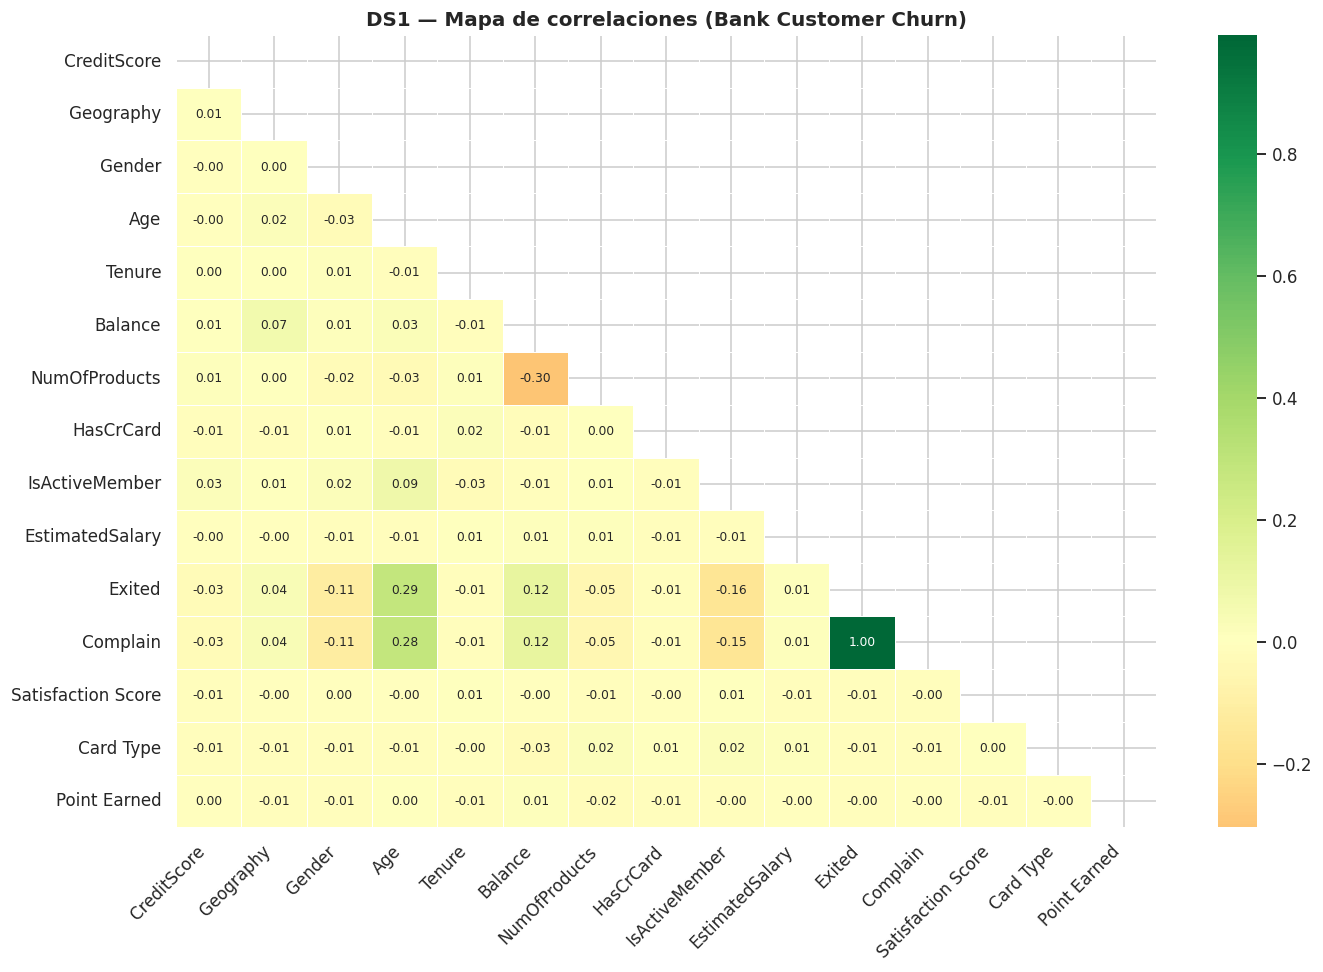


 Correlaciones con Exited (target):
Complain            0.996
Age                 0.285
IsActiveMember     -0.156
Balance             0.119
Gender             -0.106
NumOfProducts      -0.048
Geography           0.036
CreditScore        -0.027
Tenure             -0.014
EstimatedSalary     0.012
Name: Exited, dtype: object


In [ ]:
df_bank_enc = df_bank.copy()
for col in df_bank_enc.select_dtypes(include='object').columns:
    df_bank_enc[col] = pd.Categorical(df_bank_enc[col]).codes
corr1 = df_bank_enc.corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr1, dtype=bool))
sns.heatmap(corr1, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white', annot_kws={'size':8})
plt.title('DS1 — Mapa de correlaciones (Bank Customer Churn)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

print('\n Correlaciones con Exited (target):')
print(corr1['Exited'].drop('Exited').sort_values(key=abs, ascending=False).head(10).map(lambda x: f'{x:.3f}'))

## 1.5 Resumen de hallazgos — Dataset 1

| Aspecto | Detalle |
|---|---|
| **Tamaño** | 10.000 filas × 15 columnas útiles |
| **Nulos** |  Sin valores nulos |
| **Desbalance** |  casi 20% Churn vs un 80% No Churn, el dataset requiere SMOTE o `class_weight` |
| **Outliers** | Moderados en `CreditScore` y `Age`; balance bimodal (muchos en $0) |
| **Correlación clave** | `Complain` altamente correlacionado con `Exited`, hay que tener precaucion ante un posible data leakage |
| **Skewness** | `Balance` bimodal; `EstimatedSalary` casi uniforme |
| **Problemática** | **Clasificación binaria:** predecir abandono de cliente |
| **Relevancia** | Retener un cliente cuesta 5–7x menos que adquirir uno nuevo |